**IMPORTING LIBRARIES**

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

**LOADING DATA SET**

In [235]:
df=pd.read_csv('Downloads/Compressed/household_power_consumption.txt', sep=';', low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


**DATA CLEANING**

In [238]:
df = df.fillna(df.mean(numeric_only=True))

In [265]:
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])


In [266]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
DateTime                 0
Hour                     0
Day                      0
Month                    0
dtype: int64

In [267]:
df["Global_active_power"] = df["Global_active_power"].astype(float)

**CREATE TIME FEATURES**

In [268]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df["Hour"] = df["DateTime"].dt.hour
df["Day"] = df["DateTime"].dt.day
df["Month"] = df["DateTime"].dt.month

**SELECT FEATURES**

In [270]:
#Inputs (X)
x = df[[
    "Hour",
    "Day",
    "Month"
    ]]
x.head()

,Hour,Day,Month
0,17,16,12
1,17,16,12
2,17,16,12
3,17,16,12
4,17,16,12


In [271]:
#Output (y)
y = df["Global_active_power"]

**TRAIN/TEST SPLIT**

In [272]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**TRAIN MACHINE LEARNING MODEL**

In [273]:
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**MAKE PREDICTIONS**

In [274]:
y_pred = model.predict(x_test)

**EVALUATE MODEL**

In [284]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)
model = LinearRegression()
model.fit(x_train, y_train)
model.intercept_
model.coef_

MAE: 0.5697346088822018
RMSE: 0.837516572916204


array([ 0.04283816,  0.00031661, -0.01017705])

**VISUALIZE RESULTS**

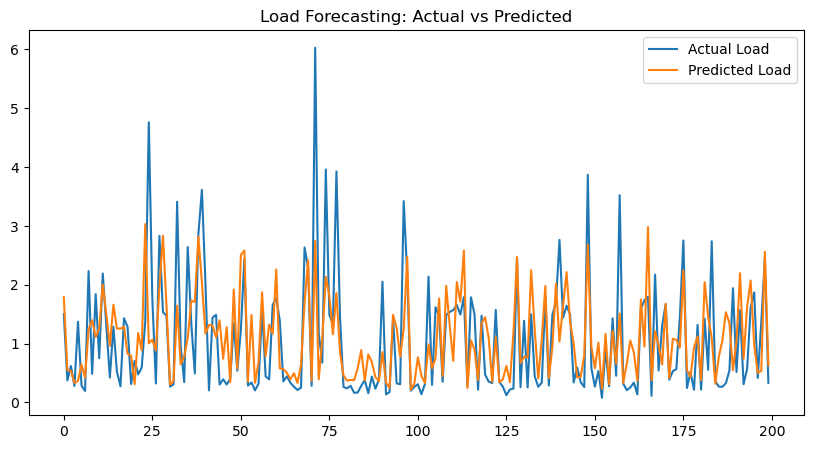

In [276]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label="Actual Load")
plt.plot(y_pred[:200], label="Predicted Load")
plt.legend()
plt.title("Load Forecasting: Actual vs Predicted")
plt.show()

In [277]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.37591700899672076
